In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import torch

import sys
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution
from tqdm import tqdm

sys.path.append("../../utils/")
from plotting import make_corner
from mahaTools import mahalanobis_dist
from ANALYSISutils import median_score

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# latent vars

In [12]:
n100 = ["Nref10000_Nbkg2000_Nsig100_3t_alt.npy","Nref10000_Nbkg2000_Nsig100_3t_null.npy"]
n200 = ["Nref10000_Nbkg2000_Nsig200_3t_alt.npy","Nref10000_Nbkg2000_Nsig200_3t_null.npy"]
n25 = ["Nref10000_Nbkg2000_Nsig25_3t_alt.npy","Nref10000_Nbkg2000_Nsig25_3t_null.npy"]
n50 = ["Nref10000_Nbkg2000_Nsig50_3t_alt.npy","Nref10000_Nbkg2000_Nsig50_3t_null.npy"]

bkg_tot = 2000
files = {
    25/bkg_tot:n25,
    50/bkg_tot:n50,
    200/bkg_tot:n200,
    100/bkg_tot:n100
}
sig_fracs = sorted(list(files.keys()))

In [14]:
base = "Mahalanobis_philToy/latent_sig4_disc4_rand4_seed2/Mahalanobis/"
zscores = []
null = np.concatenate([np.load(base+files[sf][1]) for sf in sig_fracs])
for sf in sig_fracs:
    #null = np.load(base+files[sf][1])
    alt = np.load(base+files[sf][0])
    t_empirical = np.sum(1.*(null>np.mean(alt)))*1./null.shape[0]
    if t_empirical==0:
        t_empirical = 1./null.shape[0]
    z = norm.ppf(1-t_empirical)
    zscores.append(z)

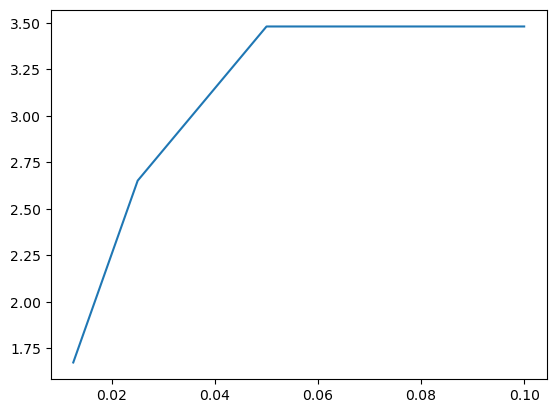

In [15]:
plt.plot(sig_fracs,zscores)

In [16]:
np.savez("philToy_latent_rand4_maha_empiricalZscore.npz",zscores=zscores,fracs=sig_fracs)

# raw vars

In [17]:
n100 = ["Nref10000_Nbkg2000_Nsig100_3t_alt.npy","Nref10000_Nbkg2000_Nsig100_3t_null.npy"]
n200 = ["Nref10000_Nbkg2000_Nsig200_3t_alt.npy","Nref10000_Nbkg2000_Nsig200_3t_null.npy"]
n25 = ["Nref10000_Nbkg2000_Nsig25_3t_alt.npy","Nref10000_Nbkg2000_Nsig25_3t_null.npy"]
n50 = ["Nref10000_Nbkg2000_Nsig50_3t_alt.npy","Nref10000_Nbkg2000_Nsig50_3t_null.npy"]

bkg_tot = 2000
files = {
    25/bkg_tot:n25,
    50/bkg_tot:n50,
    200/bkg_tot:n200,
    100/bkg_tot:n100
}
sig_fracs = sorted(list(files.keys()))

In [18]:
base = "Mahalanobis_philToy/raw_sig4_disc4_rand4_seed2/Mahalanobis/"
zscores = []
null = np.concatenate([np.load(base+files[sf][1]) for sf in sig_fracs])
for sf in sig_fracs:
    #null = np.load(base+files[sf][1])
    alt = np.load(base+files[sf][0])
    t_empirical = np.sum(1.*(null>np.mean(alt)))*1./null.shape[0]
    if t_empirical==0:
        t_empirical = 1./null.shape[0]
    z = norm.ppf(1-t_empirical)
    zscores.append(z)

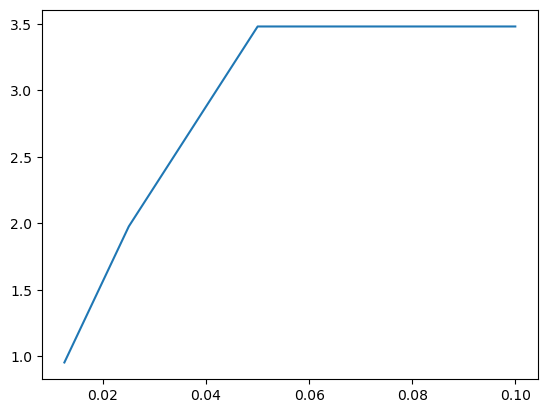

In [19]:
plt.plot(sig_fracs,zscores)

In [10]:
np.savez("philToy_raw_rand4_maha_empiricalZscore.npz",zscores=zscores,fracs=sig_fracs)